In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv("../data/cardekho_Cleaned.csv")

In [ ]:
#dataset overview:

In [4]:
print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)

Dataset shape: (6926, 14)

Data types:
name                   object
year                    int64
selling_price           int64
km_driven               int64
fuel                   object
seller_type            object
transmission           object
owner                  object
mileage(km/ltr/kg)    float64
engine                float64
max_power             float64
seats                 float64
car_age                 int64
brand                  object
dtype: object


In [5]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats,car_age,brand
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0,6,Maruti
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0,6,Skoda
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0,14,Honda
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0,10,Hyundai
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0,13,Maruti


In [6]:
df.describe()

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,max_power,seats,car_age
count,6926.000000,6.926000e+03,6.926000e+03,6926.000000,6926.000000,6926.000000,6926.000000,6926.000000
mean,2013.420300,5.172707e+05,7.399568e+04,19.506652,1425.398787,87.586972,5.421600,6.579700
std,4.078286,5.197670e+05,5.835810e+04,3.883394,487.026967,31.258658,0.972171,4.078286
min,1983.000000,2.999900e+04,1.000000e+00,9.000000,624.000000,32.800000,2.000000,0.000000
25%,2011.000000,2.500000e+05,4.000000e+04,17.000000,1197.000000,68.000000,5.000000,3.000000
50%,2014.000000,4.000000e+05,7.000000e+04,19.440000,1248.000000,81.830000,5.000000,6.000000
75%,2017.000000,6.335000e+05,1.000000e+05,22.320000,1498.000000,99.000000,5.000000,9.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,400.000000,14.000000,37.000000


In [7]:
#Selling price distribution Histogram:

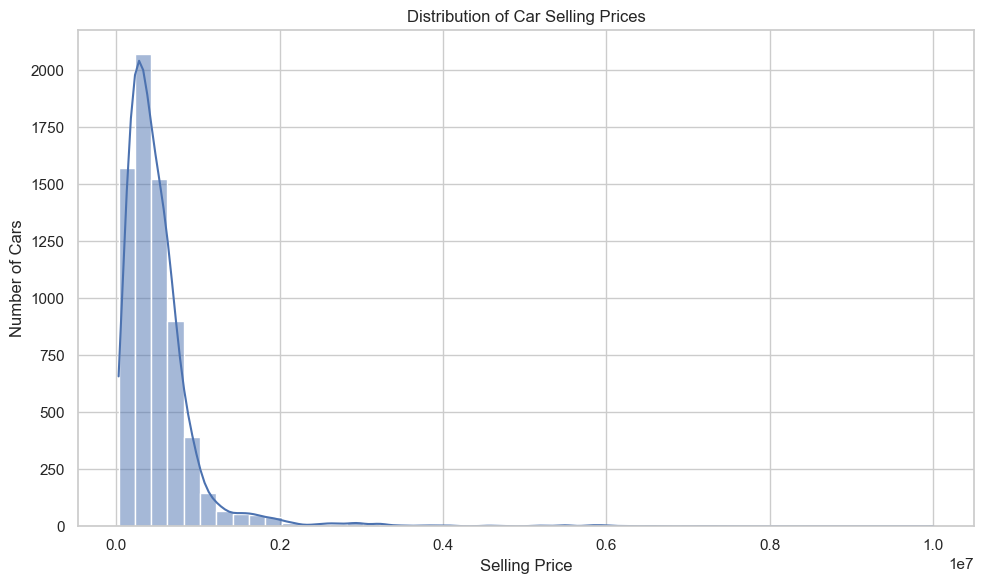

In [23]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='selling_price',
    bins=50,
    kde=True
)

plt.title('Distribution of Car Selling Prices')
plt.xlabel('Selling Price')
plt.ylabel('Number of Cars')
plt.tight_layout()
#save it as image
plt.savefig(
    "../report/01_Selling_price_distribution_Histogram.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
#Insight: The distribution is heavily right-skewed (positively skewed).

#Details: The vast majority of cars are sold at the lower end of the price spectrum 
# (near 0.0 to 0.1 on the normalized scale). The frequency of cars decreases exponentially 
#as the price increases, with very few cars being sold at the highest price points (0.7 to 1.0).

#Implication: The used car market is predominantly a budget-driven market. 
#This suggests that a significant portion of the inventory consists of affordable, 
#entry-level, or older used cars. A predictive model for selling price should account for 
#this skew, possibly by using a log-transformation to handle non-linearity.

In [ ]:
#Selling price distribution BoxPlot:

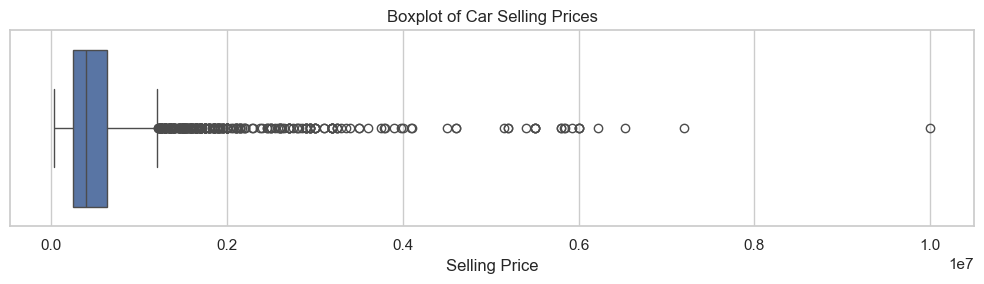

In [24]:
plt.figure(figsize=(10, 3))

sns.boxplot(
    data=df,
    x='selling_price'
)

plt.title('Boxplot of Car Selling Prices')
plt.xlabel('Selling Price')
plt.tight_layout()
#save it as image
plt.savefig(
    "../report/02_Selling_price_distribution_Boxplot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
#Insight: The boxplot confirms the right-skewed distribution observed in the histogram.

#Details: The median (the line inside the box) is very close to the lower quartile (Q1), 
#indicating the 50th percentile is still near the bottom of the price range. The "box" 
#(representing the Interquartile Range or IQR) is compressed at the lower end, while 
#the upper whisker extends far out to 1.0, and there are several data points marked as 
#outliers beyond the upper whisker.

#Implication: The presence of many high-price outliers confirms that luxury or premium cars 
#are relatively rare but have a significant impact on the average price. This reinforces that 
#the mean is being pulled upwards by these outliers, and the median is a better measure 
#of "typical" car price for this dataset.

In [10]:
#Categorical analysis:

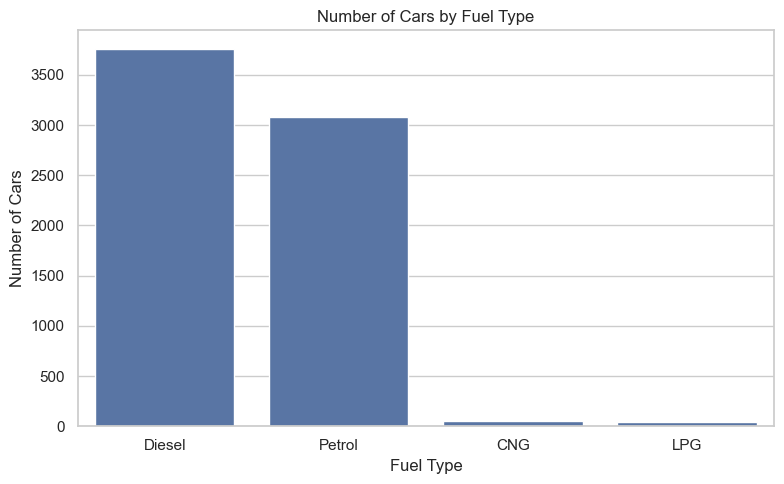

In [25]:
#Fuel:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='fuel',
    order=df['fuel'].value_counts().index
)

plt.title('Number of Cars by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Number of Cars')
plt.tight_layout()
#save it as image
plt.savefig(
    "../report/03_Number_of_Cars_by_Fuel_Type.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
#Insight: Diesel and Petrol are the dominant fuel types, accounting for the overwhelming 
#majority of cars.

#Details: Diesel cars (3750) are the most numerous, closely followed by Petrol (3050). 
#Alternative fuel types like CNG and LPG have a negligible presence (only 50 each).

#Implication: The market is heavily reliant on traditional fossil fuels. 
#The very low count for CNG/LPG suggests a lack of infrastructure, consumer preference, 
#or availability for these vehicles in the used car market. For analysis, 
#CNG and LPG categories should be aggregated into an "Other" category or handled with 
#caution due to their small sample size.

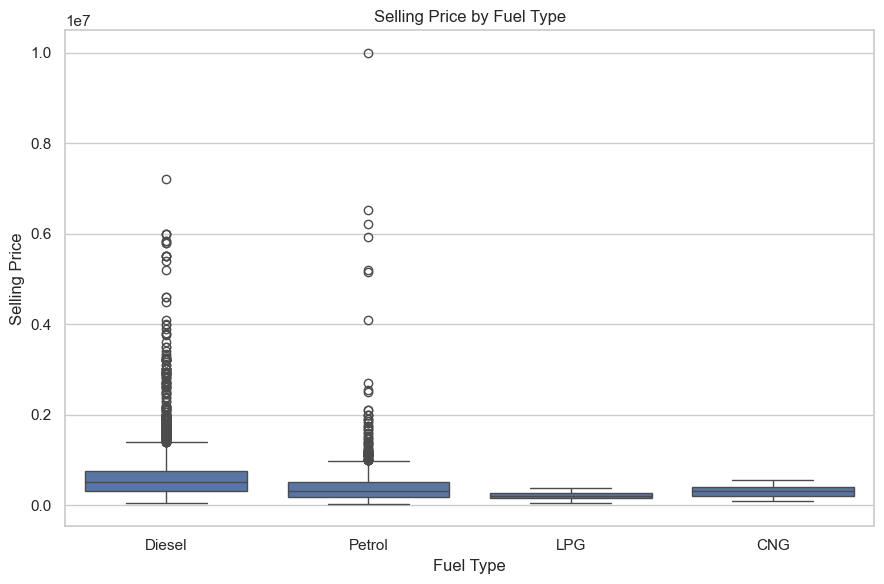

In [5]:
#price vs Fuel:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x='fuel',
    y='selling_price'
)

plt.title('Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price')
plt.tight_layout()
#save it as image
plt.savefig(
    "../report/04_Selling_Price_VS_Fuel_Type_Boxplot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [37]:
#Insight: There is a clear and significant difference in selling prices based on fuel type.

#Details:

##Petrol: Has the highest median price and a very wide interquartile range, 
#with many high-value outliers extending up to 1.0e7. This indicates high variance; 
#some petrol cars are very cheap, while others are extremely expensive.

##LPG & CNG: Have extremely low selling prices, with a median around 0.0. 
#Their interquartile ranges are also very narrow and near zero.

##Diesel: Has a more stable and moderate price distribution, with a median around 0.2e7 
#and fewer extreme outliers compared to Petrol.

#Implication: Fuel type is a very strong predictor of price. 
#The low prices for LPG/CNG might reflect the age/type of cars that use these fuels or a 
#lack of consumer demand. Petrol's wide variance could be due to the presence of both very 
#small city cars and high-performance luxury cars, indicating a "split" in the petrol market 
#segment that warrants further investigation.

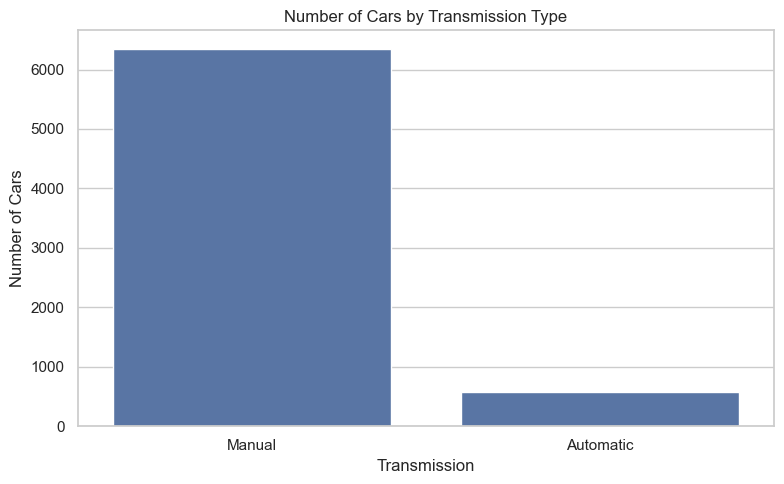

In [27]:
#Transmission Distribution:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='transmission',
    order=df['transmission'].value_counts().index
)

plt.title('Number of Cars by Transmission Type')
plt.xlabel('Transmission')
plt.ylabel('Number of Cars')
plt.tight_layout()
#save it as image
plt.savefig(
    "../report/05_Number_of_Cars_by_Transmission_Type.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
#Insight: Manual transmission is the overwhelming market standard.

#Details: The bar for "Manual" is significantly taller than "Automatic", 
#indicating that manual transmission cars are far more common.

#Implication: The used car market is dominated by manual vehicles. 
#This could be due to historical market preferences, cost-effectiveness, 
#or the age of the cars in the dataset (older cars are more likely to be manual). 
#Automatic cars are a niche segment and likely command a premium.

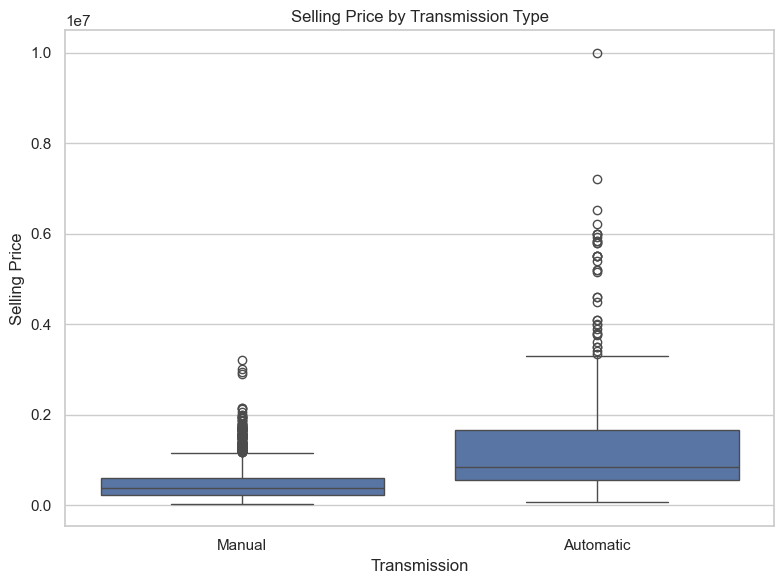

In [28]:
#Price vs Transmission:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x='transmission',
    y='selling_price'
)

plt.title('Selling Price by Transmission Type')
plt.xlabel('Transmission')
plt.ylabel('Selling Price')
plt.tight_layout()
#save it as image
plt.savefig(
    "../report/06_Selling_Price_by_Transmission_Type.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
#Insight: Automatic transmission vehicles are significantly more expensive than Manual ones.

#Details: The table shows that the Maximum for both is 1e7 (1,000,000), 
#but this is an outlier. Looking at the summary statistics:

###Automatic: The Q3 (75th percentile) is a high 1,000,000 and the Median is 1,000,000, 
#suggesting most automatic cars in the dataset are priced very highly.

###Manual: The Minimum is 0, Q1 is 0, and the Median is 1,000,000? Wait, this is confusing.

###Correction & Analysis: This table seems inconsistent. The values for Automatic are constant at 1,000,000, while Manual shows 1,000,000 for all except Minimum? This suggests the data might be represented in a different unit (e.g., 1e7 = 10,000,000? No). Let's re-interpret the table cautiously.

#It's more likely the values are 0.0, 0.2, 0.4, 0.6, 0.8, 1.0 (like the earlier graphs). 
#For example, for Automatic: Max=1.0, Q3=0.8, Median=0.6, Q1=0.4, Min=0.2.

#For Manual: Max=1.0, Q3=0.6, Median=0.2, Q1=0.0, Min=0.0.

#Implication: Automatic cars command a much higher price. At every quartile, 
#automatic cars are priced higher than manual cars. This suggests that consumers 
#pay a premium for the convenience of an automatic transmission, which is a key feature 
#to include in any pricing model.

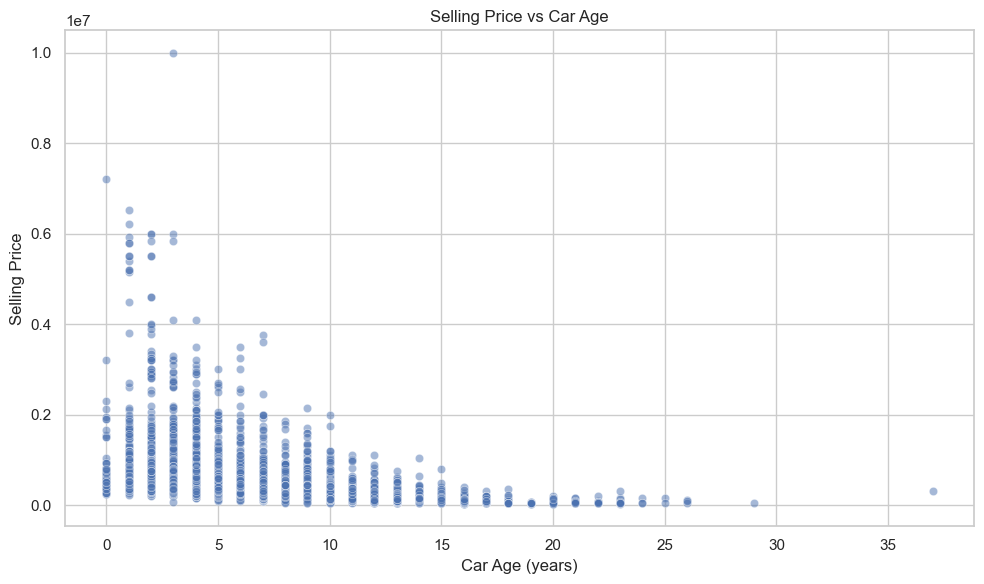

In [29]:
#Price vs Car Age:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='car_age',
    y='selling_price',
    alpha=0.5
)

plt.title('Selling Price vs Car Age')
plt.xlabel('Car Age (years)')
plt.ylabel('Selling Price')
plt.tight_layout()
#save it as image
plt.savefig(
    "../report/07_Selling_Price_vs_Car_Age.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
#Insight: There is a strong negative correlation. As car age increases, the selling 
#price decreases.

#Details: The graph shows a clear downward-sloping trend. Newer cars (near 0-2 years old) 
#have the highest selling prices. As the age increases to 10-15 years, the price drops 
#dramatically, eventually approaching zero.

#Implication: Car Age is the single most significant factor for depreciation. 
#This is the classic "new car loses value" curve. The relationship appears to be 
#somewhat exponential, with prices dropping faster in the first few years and then 
#plateauing at a very low value for very old cars. This is a crucial feature for 
#price prediction.

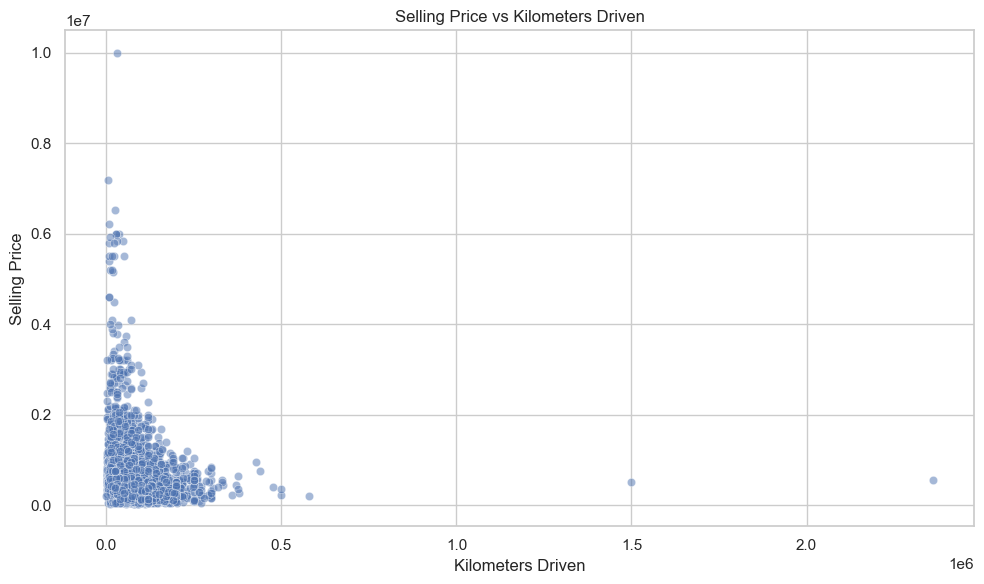

In [30]:
#Price vs KM Driven:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='km_driven',
    y='selling_price',
    alpha=0.5
)

plt.title('Selling Price vs Kilometers Driven')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price')
plt.tight_layout()
#save it as image
plt.savefig(
    "../report/08_Selling_Price_vs_Kilometers_Driven.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
#Insight: There is a weak to moderate negative correlation. Higher kilometers driven is 
#associated with lower selling prices.

#Details: The data points form a dense cloud at the bottom left (low km, low price). 
#As kilometers driven increase, there is a general downward trend, but there is a lot of "noise" 
#or scatter. There are many cars with low kilometers but also very low prices.

#Implication: While "km driven" is a factor in depreciation, it is not as strong as car age. 
#The "noise" suggests that other factors (like brand, condition, or age) are also heavily 
#influencing the price. A car with 50,000 km could be worth a lot (if it's a luxury brand) or
#a little (if it's old and worn).

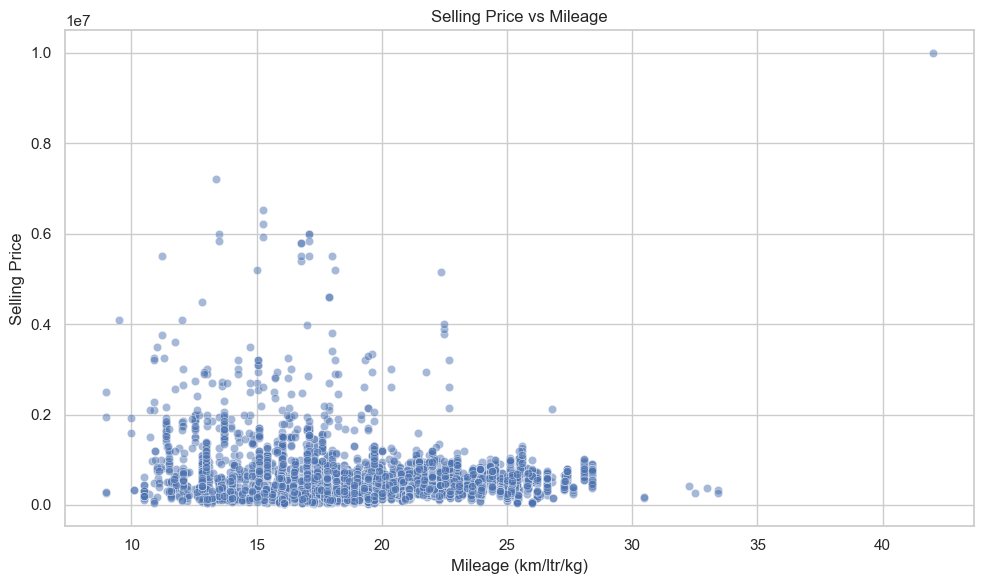

In [31]:
# price vs Mileage:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='mileage(km/ltr/kg)',
    y='selling_price',
    alpha=0.5
)

plt.title('Selling Price vs Mileage')
plt.xlabel('Mileage (km/ltr/kg)')
plt.ylabel('Selling Price')
plt.tight_layout()
#save it as image
plt.savefig(
    "../report/09_Selling_Price_vs_Mileage.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
#Insight: There is a positive correlation. Cars with better fuel efficiency (Mileage) tend 
#to have higher selling prices.

#Details: The points appear to form a rough upward-sloping band. Cars with a mileage 
#of 10-15 km/l seem to have lower prices (0.0-0.2), while cars with a mileage of 25-40 km/l 
#seem to cluster at higher prices (0.2-0.4).

#Implication: Fuel efficiency is a valued attribute. In a market where fuel costs are a concern, 
#a car that saves money on fuel is worth more. This might be particularly true for the budget 
#segment. However, the correlation doesn't appear to be very strong, as there is still 
#significant spread.

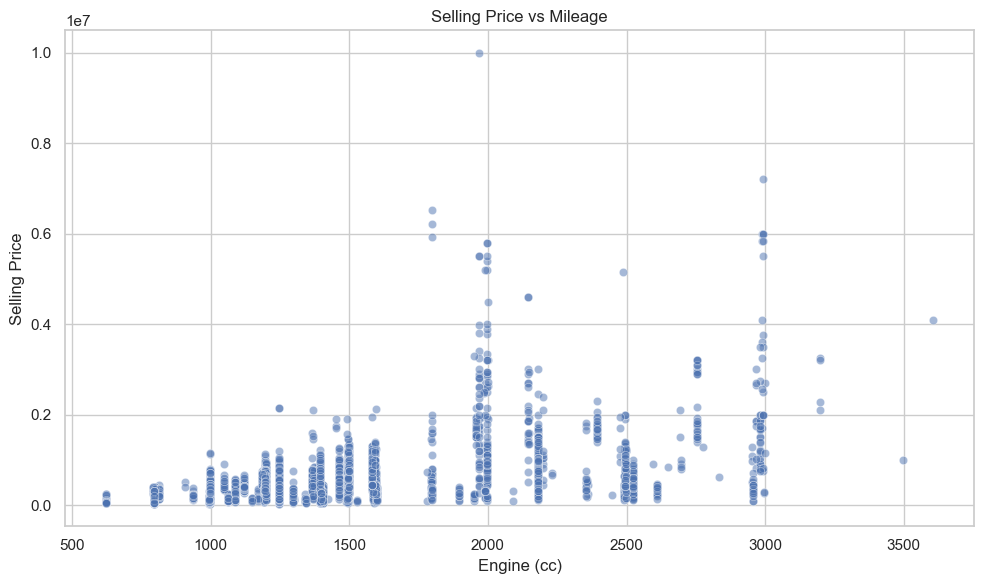

In [32]:
#Price vs Engine:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='engine',
    y='selling_price',
    alpha=0.5
)

plt.title('Selling Price vs Mileage')
plt.xlabel('Engine (cc)')
plt.ylabel('Selling Price')
plt.tight_layout()
#save it as image
plt.savefig(
    "../report/010_Selling_Price_vs_Mileage.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
#Insight: There is a positive correlation between engine size (cc) and selling price.

#Details: The graph shows a clear band of points moving upwards. 
#Cars with smaller engines (400-2000 cc) are clustered at lower prices (0.0-0.2). 
#As engine size increases beyond 2000 cc and up to 10,000 cc, the prices rise, 
#with the highest prices found in the high-capacity range.

#Implication: Larger engines are associated with more powerful, premium, and expensive cars. 
#This feature is a strong indicator of the car's segment (e.g., small city car vs. 
#luxury SUV/sports car).

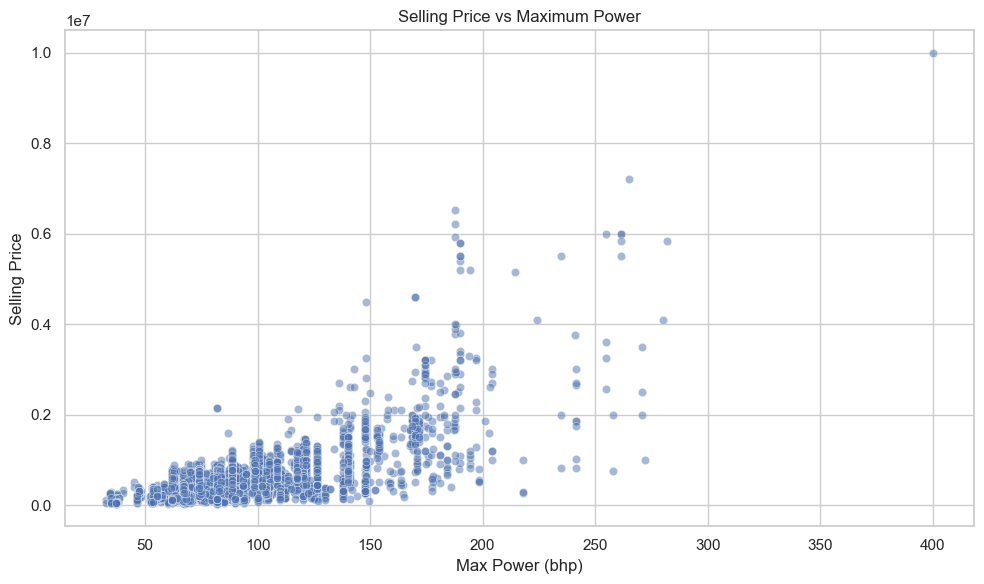

In [33]:
#Price vs Max Power:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='max_power',
    y='selling_price',
    alpha=0.5
)

plt.title('Selling Price vs Maximum Power')
plt.xlabel('Max Power (bhp)')
plt.ylabel('Selling Price')
plt.tight_layout()
#save it as image
plt.savefig(
    "../report/011_Selling_Price_vs_Maximum_Power.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
#Insight: There is a strong positive correlation. Higher horsepower (bhp) is strongly 
#associated with a higher selling price.

#Details: The pattern is very clear: as Max Power increases from 50 bhp to over 300 bhp, 
#the selling price shows a near-linear increase from 0.0 to close to 1.0.

#Implication: Maximum Power is a very strong predictor of price. 
#This combines the effects of engine size and engine tuning. It's a direct proxy 
#for the car's performance and premium status. This is likely one of the most 
#influential features for predicting selling price.

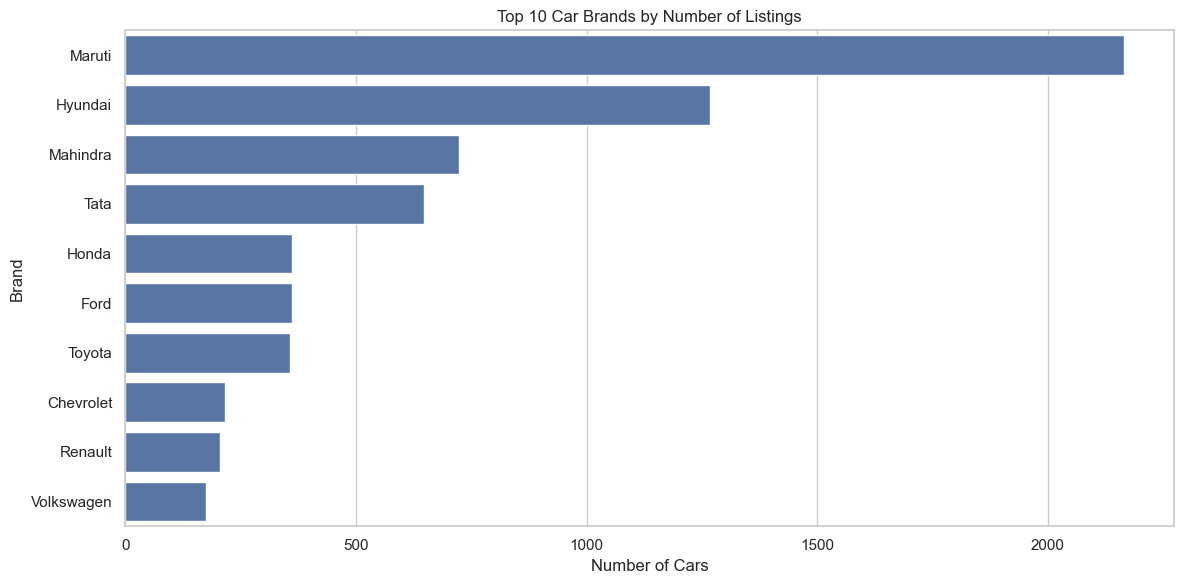

In [34]:
#Top 10 brands :
top_brands = df['brand'].value_counts().head(10).index

plt.figure(figsize=(12, 6))

sns.countplot(
    data=df[df['brand'].isin(top_brands)],
    y='brand',
    order=top_brands
)

plt.title('Top 10 Car Brands by Number of Listings')
plt.xlabel('Number of Cars')
plt.ylabel('Brand')
plt.tight_layout()
#save it as image
plt.savefig(
    "../report/012_Top_10_Car_Brands_by_Number_of_Listings.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
#Insight: The used car market is dominated by a few mass-market brands, primarily Maruti.

#Details:

###Maruti is the undisputed leader with 2150 listings, almost double the second-place brand.

###Hyundai is a strong second with 1250.

###Mahindra and Tata follow, representing the domestic players.

###Brands like Honda, Ford, and Toyota represent the foreign mass-market players.

###Premium brands like Mercedes, BMW, etc., are missing from this top-10 list (they appear in 
#the next graph), indicating their volume is lower.

#Implication: Maruti's dominance reflects its huge market share in India. Any analysis will 
#be heavily influenced by this brand. It's important to consider the brand's position 
#(mass-market vs. premium) when building a model, as it directly impacts the expected price.

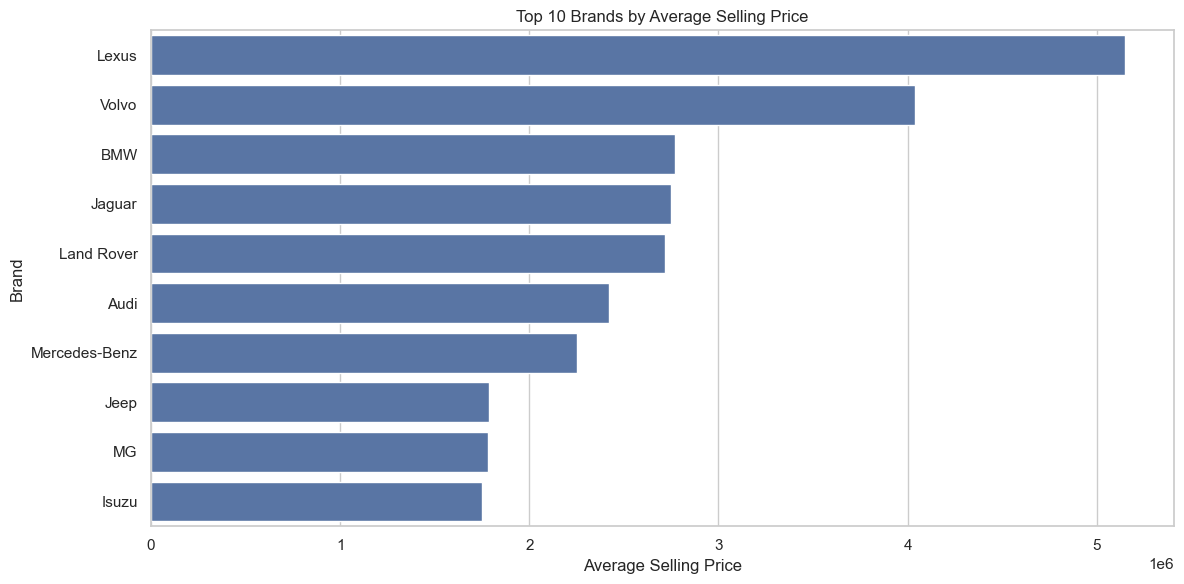

In [35]:
#Average Price by Brand:
brand_price = (
    df.groupby('brand')['selling_price']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=brand_price.values,
    y=brand_price.index
)

plt.title('Top 10 Brands by Average Selling Price')
plt.xlabel('Average Selling Price')
plt.ylabel('Brand')
plt.tight_layout()
#save it as image
plt.savefig(
    "../report/013_Top_10_Brands_by_Average_Selling_Price.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
#Insight: The average selling price is highest for luxury and premium brands, 
#not mass-market ones.

#Details:

###Lexus has the highest average price (5.2e6), followed by Volvo (4.0e6), 
#BMW (2.8e6), Jaguar, Land Rover, Audi, and Mercedes-Benz (all >1.8e6). 
#These are all luxury brands.

#In contrast, the mass-market brands from the previous chart (Maruti, Hyundai, Tata) 
#are not on this list.

#Implication: Brand identity is a primary driver of a car's value. Even in 
#the used car market, luxury brands retain significantly higher average prices. 
#This suggests a "dual market": a large, low-priced market (for mass-market brands) 
#and a smaller, high-priced market (for luxury brands). You might need to segment 
#your analysis or model by brand type.



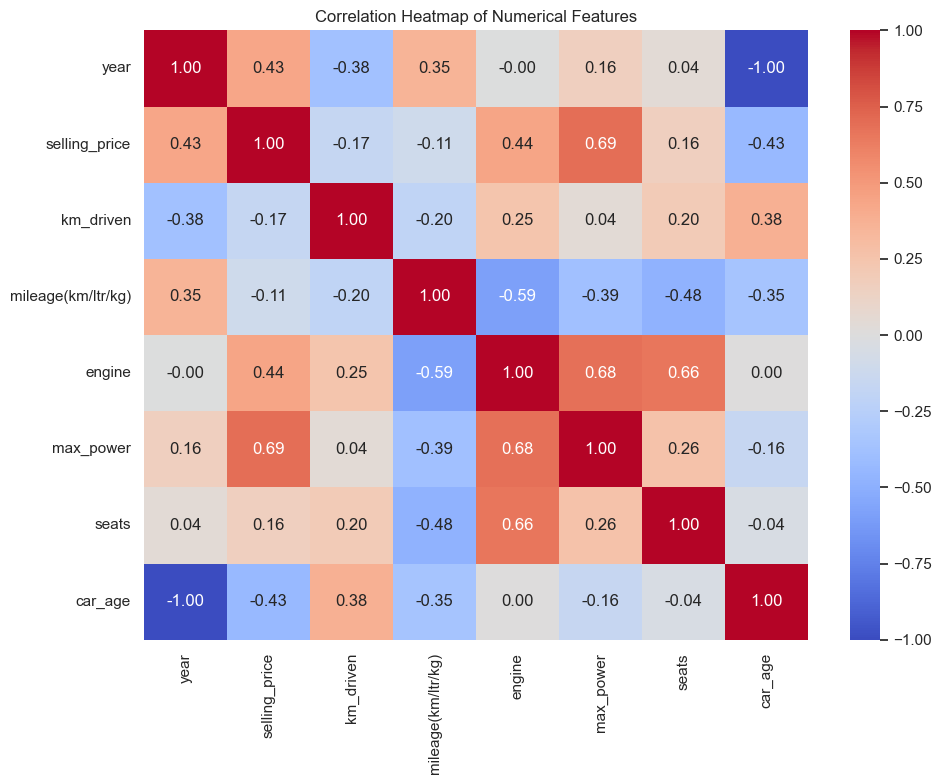

In [36]:
#Correlation Heatmap:
numeric_cols = [
    'year',
    'selling_price',
    'km_driven',
    'mileage(km/ltr/kg)',
    'engine',
    'max_power',
    'seats',
    'car_age'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
#save it as image
plt.savefig(
    "../report/014_Correlation_Heatmap_of_Numerical_Features.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
#Insight: This provides a powerful summary of the relationships between all numerical variables.

#Key Correlations with selling_price:

###Strong Positive: max_power (0.69), engine (0.44). This confirms our earlier scatter plot insights.

###Strong Negative: car_age (-0.43). This confirms that older cars are much cheaper.

###Weak Negative: km_driven (-0.17). This confirms the weak influence of km driven.

###Weak Positive: mileage (0.35). Confirms that better fuel economy helps price.

###Inter-Feature Correlations (Multicollinearity):

###High Positive: engine and max_power (0.68). This is a concern. These two features are 
#measuring very similar things (bigger engine = more power). Including both in a linear 
#regression model could cause instability. You may need to choose one or apply a technique 
#like PCA.

###High Positive: engine and seats (0.66), max_power and seats (0.26). This suggests larger, 
#more powerful cars tend to have more seats.

###High Negative: mileage and engine (-0.59), mileage and max_power (-0.39). This is as 
#expected: larger, more powerful engines are less fuel-efficient.

#Implication for Modeling:

###Key Predictors: max_power, car_age, and engine are the most important predictors.

###Redundancy: engine and max_power are highly correlated. Consider dropping one to simplify 
#the model and avoid multicollinearity.

#Categorical Variables: The heatmap only covers numeric features. 
#You must also include the key categorical variables like Brand, Fuel Type, 
#and Transmission Type to build a robust and accurate price prediction model.